In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

# Asegura que el ROOT esté en sys.path para poder importar src/*
ROOT = Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("Python:", sys.version)
print("Torch:", torch.__version__)


ROOT: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026
Python: 3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:39:55) [MSC v.1944 64 bit (AMD64)]
Torch: 2.5.1+cpu


In [3]:
import importlib

# (opcional) recarga módulos si estás editando código en caliente
import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod
import src.problems.schrodinger as sch_prob

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)
importlib.reload(sch_prob)

# ===== Imports correctos =====
from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem

from src.utils.logger import Logging

print("Imports OK.")



Imports OK.


In [4]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./prueba_barrera_dv_pasos_exito2 v05.ipynb")  # ajusta

seed = 0
run_logger = NBRunLogger("barrier", "DV", seed=seed, tag="pruebav3_barrier_pre_e1000_0_w_300_circ19_4q_2l")
run_logger.enable_autosave_figures_each_cell()

print("RUN_DIR:", run_logger.run_dir.resolve())



RUN_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\barrier\DV\20260302-182857_seed0_pruebav3_barrier_pre_e1000_0_w_300_circ19_4q_2l


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # para pruebas rápidas
print("device:", device, "| dtype:", dtype)

# ====== PARAMETROS DEL PROBLEMA: BARRERA ======
eq_params = build_eq_params(
    "barrier",
    L=1.0,
    T=0.2,
    n_level=1,      # ojo: en barrier es índice 0-based en tu exact numérica
    mass=1.0,
    hbar=1.0,
    # barrera
    V0=3.0,
    barrier_width=0.2,
    x_center=0.6,
    # malla para exact numérico
    num_grid=400,
)

print("eq_params:", eq_params)


device: cpu | dtype: torch.float32
eq_params: {'example': 'barrier', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 3.0, 'barrier_width': 0.2, 'x_center': 0.6, 'num_grid': 400}


In [6]:
# Guarda parámetros globales del problema (comunes a todas las etapas)
run_logger.save_json("eq_params.json", eq_params)


WindowsPath('results/barrier/DV/20260302-182857_seed0_pruebav3_barrier_pre_e1000_0_w_300_circ19_4q_2l/artifacts/eq_params.json')

In [7]:
from pathlib import Path
dv_file = ROOT / "src" / "nn" / "DVPDESolver.py"
txt = dv_file.read_text(encoding="utf-8", errors="ignore")

# buscamos el patrón correcto de rotación: re2 = re*c + im*s ; im2 = im*c - re*s
ok1 = ("re2 = re * c + im * s" in txt) or ("re2 = re*c + im*s" in txt)
ok2 = ("im2 = im * c - re * s" in txt) or ("im2 = im*c - re*s" in txt)

print("DVPDESolver.py:", dv_file)
print("Global-phase sign OK?:", ok1 and ok2)

if not (ok1 and ok2):
    print("\n⚠️  Parece que el signo NO está corregido.")
    print("    Corrige _apply_global_phase para implementar exp(-i ω t).")


DVPDESolver.py: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\src\nn\DVPDESolver.py
Global-phase sign OK?: True


In [8]:
def predict_psi(model, t, x):
    """Devuelve psi_pred (complejo) como tensor complejo shape [N,1]."""
    tx = torch.cat([t, x], dim=1)
    out = model(tx)
    re = out[:, 0:1]
    im = out[:, 1:2]
    return re + 1j * im

def exact_psi(problem, n_level, t, x):
    """Devuelve psi_exact (complejo) y también E."""
    re_e, im_e, E = problem["exact"](n_level, t, x)
    return (re_e + 1j * im_e), E

def density(psi):
    return (psi.real**2 + psi.imag**2)

def l2_rel(a, b, eps=1e-12):
    """L2 relativo estándar."""
    num = torch.sqrt(torch.mean(torch.abs(a - b)**2))
    den = torch.sqrt(torch.mean(torch.abs(b)**2)) + eps
    return num / den

def l2_rel_phase_invariant(psi_pred, psi_exact, eps=1e-12):
    """L2 relativo tras alinear fase global óptima alpha."""
    alpha = (torch.mean(torch.conj(psi_pred) * psi_exact) /
             (torch.mean(torch.conj(psi_pred) * psi_pred) + eps))
    psi_corr = alpha * psi_pred
    return l2_rel(psi_corr, psi_exact)

def plot_density_1d(problem, model, title="", n_pts=600):
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], n_pts, device=device_, dtype=dtype_).reshape(-1,1)

    for t_val, tag in [(0.0, "t=0"), (float(problem["T"]), f"t=T={problem['T']}")]:
        t = torch.full_like(x, t_val)
        with torch.no_grad():
            psi_p = predict_psi(model, t, x)
            psi_e, _ = exact_psi(problem, problem["n_level"], t, x)
            rho_p = density(psi_p).detach().cpu().numpy().flatten()
            rho_e = density(psi_e).detach().cpu().numpy().flatten()
            x_np  = x.detach().cpu().numpy().flatten()

        plt.figure(figsize=(7.2,3.4))
        plt.plot(x_np, rho_e, label="Exact")
        plt.plot(x_np, rho_p, "--", label="Pred")
        plt.title(f"{title} |psi(x,{tag})|^2")
        plt.xlabel("x")
        plt.ylabel("|psi|^2")
        plt.legend()
        plt.tight_layout()
        plt.show()

def quick_metrics(problem, model, t_val=None, n_pts=400):
    """Imprime L2 complejo, L2 fase-invariante y L2 densidad."""
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], n_pts, device=device_, dtype=dtype_).reshape(-1,1)
    if t_val is None:
        t_val = float(problem["T"])
    t = torch.full_like(x, float(t_val))

    with torch.no_grad():
        psi_p = predict_psi(model, t, x)
        psi_e, E = exact_psi(problem, problem["n_level"], t, x)
        rho_p = density(psi_p)
        rho_e = density(psi_e)

        l2_c   = l2_rel(psi_p, psi_e).item()
        l2_ph  = l2_rel_phase_invariant(psi_p, psi_e).item()
        l2_rho = l2_rel(rho_p, rho_e).item()

    print(f"[Metrics @ t={t_val}] L2_complex={l2_c:.4f} | L2_phase={l2_ph:.4f} | L2_density={l2_rho:.4f}")
    return E


In [9]:
problem = build_problem(eq_params, device=device, dtype=dtype)

args_stage1 = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",

    # training (rápido)
    "epochs": 1000,
    "warmup_epochs": 300,
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 5,

    # losses: SOLO IC (PDE apagado)
    "w_pde": 1.0,
    "w_pde_i": 1.0,     # irrelevante si w_pde=0
    "w_ic": 800.0,
    "w_ic_i": 5.0,
    "w_norm": 0.0,

    # BC dura
    "hard_bc": True,
    "w_bc": 0.0,
    "hard_bc_power": 1.0,
    "hard_bc_scale": 4.0,

    # IC sampling / val
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,

    # DV circuit
    "num_qubits": 4,
    "num_quantum_layers": 2,
    "shots": None,
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "farhi",  # options: "alternating_layer_tdcnot", farhi , sim_circ_15 ,sim_circ_19, sim_circ_5, layered_circuit

    # hybrid net
    "classic_network": [2, 64, 64, 2],

    # performance / métricas
    "pde_chunk_size": 64,
    "l2_every": 5,

    # fase global (se mantiene igual en ambas etapas)
    "global_phase": True,
    "global_phase_spatial_only": True,
    "global_phase_omega_init": 5.0,
    "use_lbfgs": False,

    # estabilidad de ángulos (si tu DVPDESolver lo soporta)
    "angle_squash": True,
}
from pathlib import Path
ckpt_dir = Path(run_logger.run_dir) / "checkpoints"
logger = Logging(str(ckpt_dir), f"barrier_DV_seed")
model = DVPDESolver(args_stage1, logger=Logging(ROOT / "results"), device=device).to(device)
print("Model dtype:", next(model.parameters()).dtype)


Model dtype: torch.float32


In [10]:
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)

Trainable params: {'total': 915, 'quantum': 12, 'classical': 903}


In [11]:
import logging, sys
from pathlib import Path
from contextlib import contextmanager

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)
    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[logging.StreamHandler(sys.stdout),
                  logging.FileHandler(log_file, encoding="utf-8")],
        force=True,
    )
    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False
    sys.stdout.flush()

@contextmanager
def stage(stage_id: str, desc: str, args_snapshot: dict, train_kwargs: dict):
    """
    Crea subcarpeta por etapa y deja TODO lo de esa etapa ahí:
    - artifacts/<stage_id>/: stage_meta.json, python.log, curvas parseadas, etc.
    - figures/<stage_id>/: todas las figuras de esa etapa
    """
    old_art, old_fig = run_logger.art_dir, run_logger.fig_dir

    stage_art = old_art / stage_id
    stage_fig = old_fig / stage_id
    stage_art.mkdir(parents=True, exist_ok=True)
    stage_fig.mkdir(parents=True, exist_ok=True)

    # redirige escrituras del run_logger a carpeta de etapa
    run_logger.art_dir = stage_art
    run_logger.fig_dir = stage_fig

    # logging live + archivo (por etapa)
    force_live_logging(stage_art / "python.log", level=logging.INFO)

    # evita duplicados: que SOLO el root escriba
    lg = logging.getLogger("src.utils.logger")
    lg.handlers.clear()
    lg.propagate = True
    lg.disabled = False
    lg.setLevel(logging.INFO)

    # guarda snapshot de parámetros de la etapa
    run_logger.save_json("stage_meta.json", {
        "stage_id": stage_id,
        "description": desc,
        "train_kwargs": train_kwargs,
        "args_snapshot": args_snapshot,
    })

    try:
        yield
    finally:
        # fuerza guardado de figuras pendientes
        run_logger.flush_figures()

        # parsea el log de ESA etapa (queda todo dentro de stage_art)
        try:
            run_logger.parse_schrodinger_train_log(log_name="python.log")
        except TypeError:
            # por si tu versión no acepta log_name
            run_logger.parse_schrodinger_train_log()

        # regresa a carpetas globales
        run_logger.art_dir, run_logger.fig_dir = old_art, old_fig


In [12]:
import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)

    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, encoding="utf-8"),
        ],
        force=True,
    )

    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

force_live_logging(run_logger.art_dir / "python.log")


In [13]:
import logging
lg = logging.getLogger("src.utils.logger")
lg.handlers.clear()
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


INFO:src.utils.logger:The circuit used in the study:
INFO:src.utils.logger:It: 1, Loss: 1.592e+03, Loss_res: 1.391e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.990e+00, Loss_norm: 5.909e-01, Loss_gauge: 0.000e+00, w_pde: 3.33e-03, L^2_error: 1.058e+00, lr: 1.000e-03, Time: 6.06e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\2026-03-02_18-28-58-364106\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\2026-03-02_18-28-58-364106\model_weights.pth
INFO:src.utils.logger:It: 5, Loss: 1.122e+03, Loss_res: 1.496e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.402e+00, Loss_norm: 8.526e-01, Loss_gauge: 0.000e+00, w_pde: 1.67e-02, L^2_error: 9.804e-01, lr: 1.000e-03, Time: 2.13e+01
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\2026-03-02_18-28-58-364106\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Downl

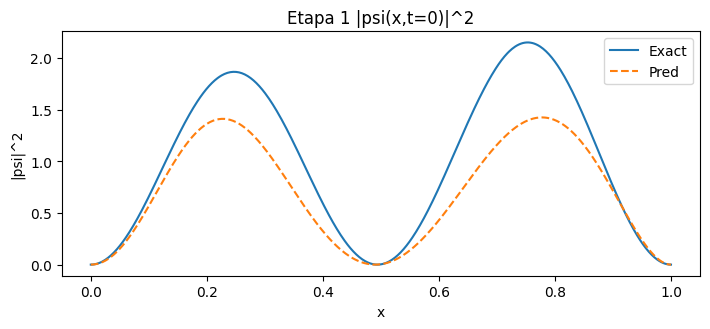

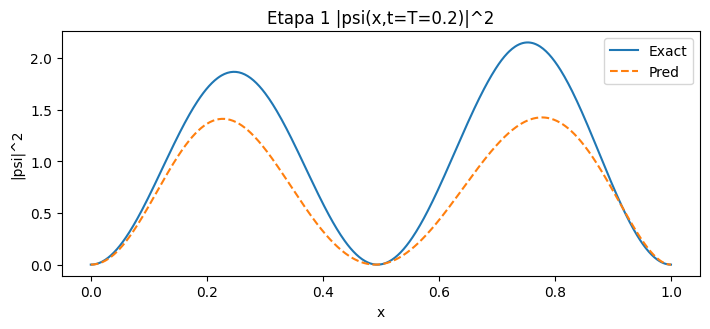

[Metrics @ t=0.0] L2_complex=0.1738 | L2_phase=0.0783 | L2_density=0.3132


In [14]:
with stage(
    stage_id="stage1_ic_only",
    desc="Etapa 1: entrenamiento solo con condición inicial (w_pde=0)",
    args_snapshot=args_stage1,                      # tu dict stage1
    train_kwargs={"N_f": 512, "N_b": 0, "N_0": 1000}
):
    train(model, N_f=512, N_b=0, N_0=1000)

    print("\nEtapa 1 (IC-only) terminada.")
    plot_density_1d(problem, model, title="Etapa 1")
    E = quick_metrics(problem, model, t_val=0.0)
    run_logger.save_json("metrics.json", {"t_val": 0.0, "metrics": E})

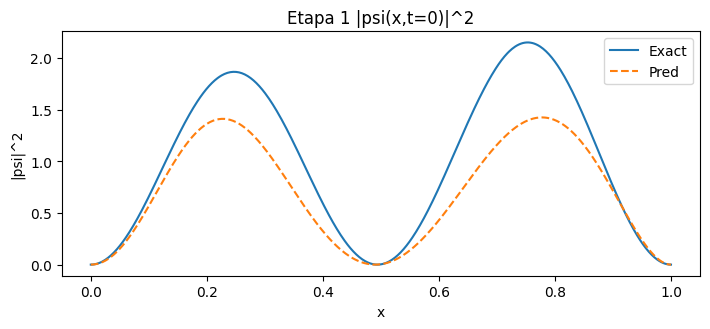

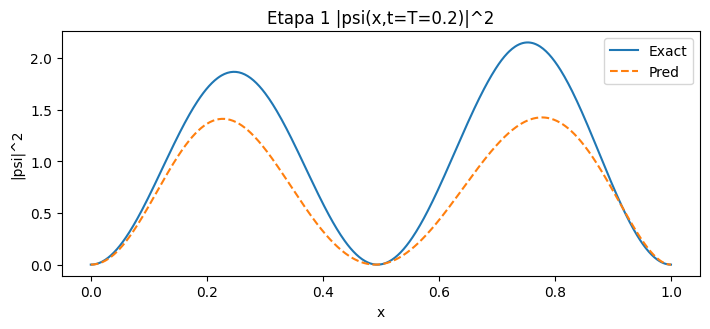

[Metrics @ t=0.0] L2_complex=0.1738 | L2_phase=0.0783 | L2_density=0.3132


WindowsPath('results/barrier/DV/20260302-182857_seed0_pruebav3_barrier_pre_e1000_0_w_300_circ19_4q_2l/artifacts/metrics.json')

In [15]:
plot_density_1d(problem, model, title="Etapa 1")
E = quick_metrics(problem, model, t_val=0.0)
run_logger.save_json("metrics.json", {"t_val": 0.0, "metrics": E})

In [16]:
# Calcula E/hbar usando exact (en cualquier x0 sirve)
device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype

x0 = torch.tensor([[0.37]], device=device_, dtype=dtype_)
t0 = torch.zeros_like(x0)

with torch.no_grad():
    psi_e0, E = exact_psi(problem, problem["n_level"], t0, x0)
omega_star = float((E / problem["hbar"]).detach().cpu())

print("E =", float(E.detach().cpu()))
print("omega_star = E/hbar =", omega_star)

# set + freeze
if hasattr(model, "global_phase_omega"):
    model.global_phase_omega.data.fill_(omega_star)
    model.global_phase_omega.requires_grad_(False)
    print("✅ omega fijada y congelada.")
else:
    print("⚠️ Tu modelo no tiene global_phase_omega. Revisa DVPDESolver.")


E = 20.217073440551758
omega_star = E/hbar = 20.217073440551758
✅ omega fijada y congelada.


In [ ]:
# Actualiza args dentro del modelo (train() lee model.args)
model.args["epochs"] = 800
model.args["warmup_epochs"] = 160

model.args["w_pde"] = 1.0
model.args["w_pde_i"] = 1.0       # importante: NO 10
model.args["w_norm"] = 10.0

# dejamos IC igual
model.args["w_ic"] = 800.0
model.args["w_ic_i"] = 5.0

model.args["use_lbfgs"] = False
model.args["angle_squash"] = True

args_stage2 = dict(model.args)   # snapshot justo DESPUÉS de tus cambios de etapa 2

with stage(
    stage_id="stage2_physics",
    desc="Etapa 2: activa PDE + normalización (w_pde=1, w_norm=10, warmup=100)",
    args_snapshot=args_stage2,
    train_kwargs={"N_f": 512, "N_b": 0, "N_0": 1000}
):
    train(model, N_f=512, N_b=0, N_0=1000)

    print("\nEtapa 2 (Physics-informed) terminada.")
    plot_density_1d(problem, model, title="Etapa 2")
    E = quick_metrics(problem, model, t_val=float(problem["T"]))
    run_logger.save_json("metrics.json", {"t_val": float(problem["T"]), "metrics": E})


' # Actualiza args dentro del modelo (train() lee model.args)\nmodel.args["epochs"] = 800\nmodel.args["warmup_epochs"] = 160\n\nmodel.args["w_pde"] = 1.0\nmodel.args["w_pde_i"] = 1.0       # importante: NO 10\nmodel.args["w_norm"] = 10.0\n\n# dejamos IC igual\nmodel.args["w_ic"] = 800.0\nmodel.args["w_ic_i"] = 5.0\n\nmodel.args["use_lbfgs"] = False\nmodel.args["angle_squash"] = True\n\nargs_stage2 = dict(model.args)   # snapshot justo DESPUÉS de tus cambios de etapa 2\n\nwith stage(\n    stage_id="stage2_physics",\n    desc="Etapa 2: activa PDE + normalización (w_pde=1, w_norm=10, warmup=100)",\n    args_snapshot=args_stage2,\n    train_kwargs={"N_f": 512, "N_b": 0, "N_0": 1000}\n):\n    train(model, N_f=512, N_b=0, N_0=1000)\n\n    print("\nEtapa 2 (Physics-informed) terminada.")\n    plot_density_1d(problem, model, title="Etapa 2")\n    E = quick_metrics(problem, model, t_val=float(problem["T"]))\n    run_logger.save_json("metrics.json", {"t_val": float(problem["T"]), "metrics": E}) 

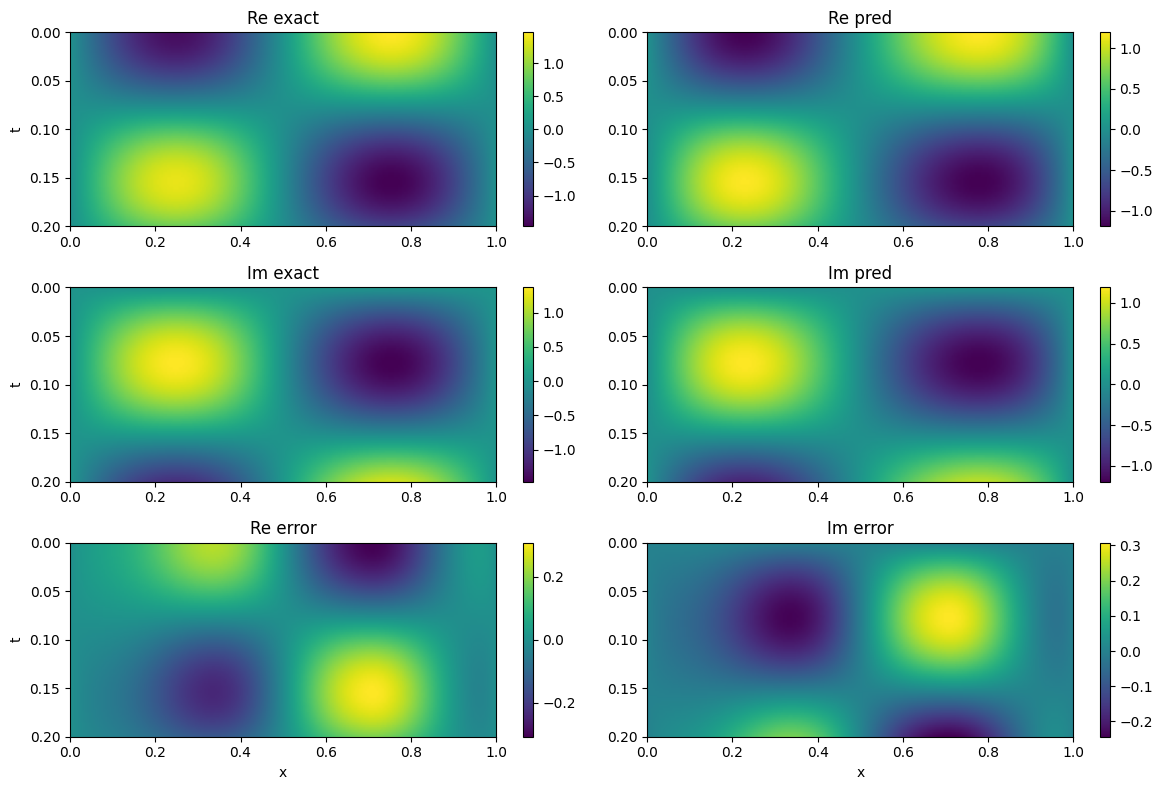

In [18]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()


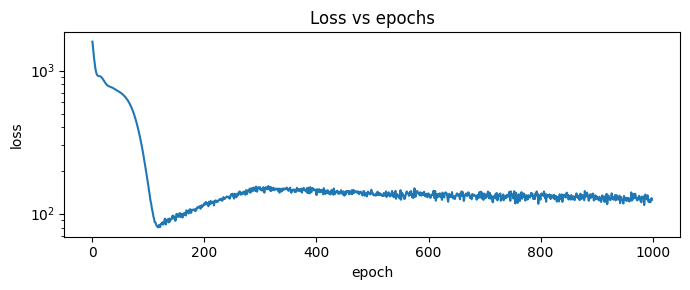

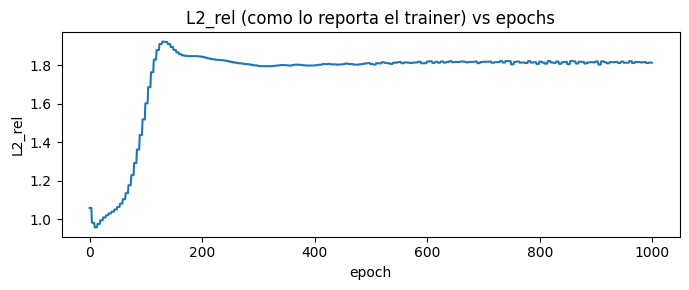

In [19]:
loss_hist = np.array(getattr(model, "loss_history", []), dtype=float)
l2_hist   = np.array(getattr(model, "l2_rel_history", []), dtype=float)

plt.figure(figsize=(7,3))
if len(loss_hist) > 0:
    plt.plot(loss_hist)
plt.yscale("log")
plt.title("Loss vs epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
if len(l2_hist) > 0:
    plt.plot(l2_hist)
plt.title("L2_rel (como lo reporta el trainer) vs epochs")
plt.xlabel("epoch")
plt.ylabel("L2_rel")
plt.tight_layout()
plt.show()


In [20]:
run_logger.flush_figures()
print("Figuras guardadas:", len(list(run_logger.fig_dir.glob("*.png"))))

Figuras guardadas: 5


In [21]:
import json
import csv
from datetime import datetime
from pathlib import Path

import torch

# --- Requiere: model, eq_params, run_logger (y idealmente device/dtype/args si existen) ---
assert "model" in globals(), "No encuentro 'model'. Ejecuta esta celda después de entrenar."
assert "eq_params" in globals(), "No encuentro 'eq_params'."
assert "run_logger" in globals(), "No encuentro 'run_logger'."

# ---------- Utils ----------
def _to_path(x):
    try:
        return Path(x)
    except Exception:
        return Path(str(x))

def _safe_get(d, key, default=None):
    try:
        return d.get(key, default)
    except Exception:
        return default

def _write_json(path: Path, obj: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def _model_eval(model, t, x):
    """Soporta model([t,x]) o model(t,x) según tu API."""
    try:
        return model(torch.cat([t, x], dim=1))
    except Exception:
        return model(t, x)

def _l2_rel_prob(prob_pred: torch.Tensor, prob_exact: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.sqrt(torch.mean((prob_pred - prob_exact) ** 2))
    den = torch.sqrt(torch.mean(prob_exact ** 2)) + eps
    return (num / den).item()

def _find_results_root_from_run_logger(run_logger):
    """Intenta encontrar carpeta 'results' a partir de run_logger.run_dir; si no, usa ./results."""
    run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
    # caso 1: alguna carpeta padre se llama "results"
    for p in [run_dir] + list(run_dir.parents):
        if p.name.lower() == "results":
            return p
    # caso 2: algún padre contiene una carpeta llamada "results"
    for p in run_dir.parents:
        cand = p / "results"
        if cand.exists() and cand.is_dir():
            return cand
    # fallback
    return (Path(".") / "results").resolve()

def _append_or_update_csv(csv_path: Path, row: dict, key_col: str = "run_dir"):
    """
    Agrega una fila al CSV. Si ya existe una fila con el mismo key_col (p.ej. run_dir), la reemplaza.
    Funciona sin pandas (solo stdlib).
    """
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    rows = []
    cols = list(row.keys())

    if csv_path.exists():
        with open(csv_path, "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            old_cols = reader.fieldnames or []
            cols = list(dict.fromkeys(old_cols + cols))  # unión preservando orden
            for r in reader:
                rows.append(r)

        # filtra si ya existe esa corrida
        new_rows = []
        for r in rows:
            if r.get(key_col, "") != str(row.get(key_col, "")):
                new_rows.append(r)
        rows = new_rows

    # agrega la fila nueva
    # asegura todas las columnas
    row_filled = {c: row.get(c, "") for c in cols}
    rows.append(row_filled)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()
        writer.writerows(rows)

# ---------- Construye pb / exact ----------
from src.problems.schrodinger.problem import build_problem

# dtype/device robusto
device_val = globals().get("device", "cpu")
dev = torch.device(device_val) if not isinstance(device_val, torch.device) else device_val

dtype_str = str(globals().get("dtype", _safe_get(getattr(model, "args", {}), "dtype", "float64")))
torch_dtype = torch.float64 if "64" in dtype_str else torch.float32

pb = build_problem(eq_params, device=dev, dtype=torch_dtype)

# eval grid
num_x = int(_safe_get(eq_params, "num_grid", 800))
x = torch.linspace(pb["x_min"], pb["x_max"], num_x, device=dev, dtype=pb["dtype"]).reshape(-1, 1)

T = float(pb["T"])
t_fracs = [0.0, 0.25, 0.50, 0.75, 1.0]
t_eval = torch.tensor([f * T for f in t_fracs], device=dev, dtype=pb["dtype"]).reshape(-1, 1)

# Detecta exacta
has_exact = ("exact" in pb) and callable(pb["exact"])

series = []
l2_rel_psi_T = None
l2_rel_prob_T = None

with torch.no_grad():
    for ti in t_eval:
        t = ti.repeat(x.shape[0], 1)
        pred = _model_eval(model, t, x)
        pr, pi = pred[:, 0:1], pred[:, 1:2]

        rec = {"t": float(ti.item())}

        if has_exact:
            er, ei, _ = pb["exact"](pb["n_level"], t, x)

            # L2 relativo de psi (Re+Im)
            l2_abs_psi = torch.sqrt(torch.mean((pr - er) ** 2 + (pi - ei) ** 2))
            ref_psi = torch.sqrt(torch.mean(er ** 2 + ei ** 2)) + 1e-12
            rec["l2_rel_psi"] = float((l2_abs_psi / ref_psi).item())

            # L2 relativo de |psi|^2
            prob_pred = pr ** 2 + pi ** 2
            prob_exact = er ** 2 + ei ** 2
            rec["l2_rel_prob"] = float(_l2_rel_prob(prob_pred, prob_exact))

        series.append(rec)

# extrae T
if has_exact and len(series) > 0:
    l2_rel_psi_T = series[-1].get("l2_rel_psi", None)
    l2_rel_prob_T = series[-1].get("l2_rel_prob", None)

# Boundary check (genérico: xmin/xmax)
ts = torch.linspace(0.0, T, 20, device=dev, dtype=pb["dtype"]).reshape(-1, 1)
x_min = torch.full_like(ts, float(pb["x_min"]))
x_max = torch.full_like(ts, float(pb["x_max"]))

with torch.no_grad():
    psi_min = _model_eval(model, ts, x_min)
    psi_max = _model_eval(model, ts, x_max)

bdry_xmin = torch.sqrt(psi_min[:, 0] ** 2 + psi_min[:, 1] ** 2).max().item()
bdry_xmax = torch.sqrt(psi_max[:, 0] ** 2 + psi_max[:, 1] ** 2).max().item()

# ---------- Metadata (reutilizable en todos) ----------
args = globals().get("args", getattr(model, "args", {})) or {}
potential = str(getattr(run_logger, "problem", _safe_get(eq_params, "potential", _safe_get(eq_params, "name", "unknown"))))
solver = str(getattr(run_logger, "solver", getattr(run_logger, "solver_type", _safe_get(args, "solver_type", "unknown"))))
seed = getattr(run_logger, "seed", _safe_get(args, "seed", None))
tag = getattr(run_logger, "tag", _safe_get(args, "tag", ""))

run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
art_dir = _to_path(getattr(run_logger, "art_dir", run_dir / "artifacts")).resolve()

# parámetros entrenables (total)
n_params_total = int(sum(p.numel() for p in model.parameters() if p.requires_grad))

# si existe una función de conteo detallado (DV notebooks), úsala
n_params_quantum = ""
n_params_classical = ""
if "count_trainable_params" in globals() and callable(globals()["count_trainable_params"]):
    try:
        out = globals()["count_trainable_params"](model)
        if isinstance(out, dict):
            n_params_total = int(out.get("total", n_params_total))
            n_params_quantum = int(out.get("quantum", ""))
            n_params_classical = int(out.get("classical", ""))
        elif isinstance(out, (tuple, list)) and len(out) >= 3:
            n_params_total = int(out[0])
            n_params_quantum = int(out[1])
            n_params_classical = int(out[2])
    except Exception:
        pass

# identifica arquitectura / ansatz / encoding (sin forzar que existan)
classic_network = _safe_get(args, "classic_network", "")
num_qubits = _safe_get(args, "num_qubits", "")
num_layers = _safe_get(args, "num_quantum_layers", _safe_get(args, "num_layers", ""))
q_ansatz = _safe_get(args, "q_ansatz", "")
encoding = _safe_get(args, "encoding", "")

arch_repr = ""
if q_ansatz or num_qubits or num_layers:
    arch_repr = f"DV(q={num_qubits}, L={num_layers}, ansatz={q_ansatz}, enc={encoding}, classic={classic_network})"
else:
    arch_repr = f"PINN(classic={classic_network})"

# epochs/lr y puntos si están disponibles (si no, quedan vacíos)
epochs = _safe_get(args, "epochs", "")
lr = _safe_get(args, "lr", "")
N_f = globals().get("N_f", _safe_get(args, "N_f", ""))
N_b = globals().get("N_b", _safe_get(args, "N_b", ""))
N_0 = globals().get("N_0", _safe_get(args, "N_0", ""))

# ---------- Guardado JSON en artifacts ----------
metrics = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "potential": potential,
    "solver": solver,
    "seed": seed,
    "tag": tag,
    "run_dir": str(run_dir),
    "art_dir": str(art_dir),
    "dtype": dtype_str,
    "device": str(dev),

    "n_params_total": n_params_total,
    "n_params_quantum": n_params_quantum,
    "n_params_classical": n_params_classical,

    "epochs": epochs,
    "lr": lr,
    "N_f": N_f,
    "N_b": N_b,
    "N_0": N_0,

    "arch_repr": arch_repr,
    "classic_network": str(classic_network),
    "num_qubits": str(num_qubits),
    "num_quantum_layers": str(num_layers),
    "q_ansatz": str(q_ansatz),
    "encoding": str(encoding),

    # --- métricas mínimas tesis ---
    "has_exact": bool(has_exact),
    "l2_rel_psi_T": l2_rel_psi_T,
    "l2_rel_prob_T": l2_rel_prob_T,
    "bdry_max_abs_psi_xmin": float(bdry_xmin),
    "bdry_max_abs_psi_xmax": float(bdry_xmax),

    # evidencia temporal
    "series": series,
}

art_dir.mkdir(parents=True, exist_ok=True)
metrics_path = art_dir / "metrics_min.json"
_write_json(metrics_path, metrics)

# ---------- CSV global reutilizable ----------
results_root = _find_results_root_from_run_logger(run_logger)
summary_csv = results_root / "summary" / "summary_runs.csv"

row = {
    "timestamp": metrics["timestamp"],
    "potential": metrics["potential"],
    "solver": metrics["solver"],
    "seed": metrics["seed"],
    "tag": metrics["tag"],
    "run_dir": metrics["run_dir"],
    "n_params_total": metrics["n_params_total"],
    "n_params_quantum": metrics["n_params_quantum"],
    "n_params_classical": metrics["n_params_classical"],
    "epochs": metrics["epochs"],
    "lr": metrics["lr"],
    "N_f": metrics["N_f"],
    "N_b": metrics["N_b"],
    "N_0": metrics["N_0"],
    "dtype": metrics["dtype"],
    "device": metrics["device"],
    "arch_repr": metrics["arch_repr"],
    "q_ansatz": metrics["q_ansatz"],
    "encoding": metrics["encoding"],
    "num_qubits": metrics["num_qubits"],
    "num_quantum_layers": metrics["num_quantum_layers"],
    "classic_network": metrics["classic_network"],
    "has_exact": metrics["has_exact"],
    "l2_rel_psi_T": metrics["l2_rel_psi_T"],
    "l2_rel_prob_T": metrics["l2_rel_prob_T"],
    "bdry_max_abs_psi_xmin": metrics["bdry_max_abs_psi_xmin"],
    "bdry_max_abs_psi_xmax": metrics["bdry_max_abs_psi_xmax"],
    "metrics_json": str(metrics_path),
}

_append_or_update_csv(summary_csv, row, key_col="run_dir")

print("\n[OK] Guardado:")
print(" - metrics_min.json:", metrics_path.resolve())
print(" - summary CSV     :", summary_csv.resolve())
print("\nResumen (t=T):")
print(" - L2_rel(psi)      :", row["l2_rel_psi_T"])
print(" - L2_rel(|psi|^2)  :", row["l2_rel_prob_T"])
print(" - max|psi|(xmin)   :", row["bdry_max_abs_psi_xmin"])
print(" - max|psi|(xmax)   :", row["bdry_max_abs_psi_xmax"])


[OK] Guardado:
 - metrics_min.json: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\barrier\DV\20260302-182857_seed0_pruebav3_barrier_pre_e1000_0_w_300_circ19_4q_2l\artifacts\metrics_min.json
 - summary CSV     : C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\summary\summary_runs.csv

Resumen (t=T):
 - L2_rel(psi)      : 0.1738319844007492
 - L2_rel(|psi|^2)  : 0.3131527602672577
 - max|psi|(xmin)   : 0.0
 - max|psi|(xmax)   : 0.0
